# **Question no 01:**

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [21]:
# Load Data
df = pd.read_csv('Daily Commute Stress and Logistics survey.csv')

In [22]:
df.head()

,Timestamp,Full Name,Email Address,Age,"Q1. What is your primary mode of transportation for your daily commute (e.g., to university, office, or market)?",Q2. What is the approximate one-way distance of your daily commute (in Kilometers)? (Enter numbers only),Q3. How much does your one-way commute cost you daily on average? (Enter 0 if you walk. Enter numbers only),Q4. How long does your one-way commute usually take?,Q5. Do you feel highly stressed or exhausted due to your daily commute?,"Q6. If you use a private vehicle (Car/Motorcycle), what is your estimated monthly expenditure on fuel? (Enter numbers only)","Q7. If you use Public Transport or Ride-hailing services, what is the biggest issue you face?",Q8. Are you late to your destination 3 or more times a month due to traffic jams?,Q9. How do you usually pass the time during your commute?,"Q10. If budget was not an issue, would you change your primary mode of transport?"
0,2026/03/11 4:22:03 PM GMT+5,Syed Waleed Hussain,syedwaleedhussain89@gmail.com,22,"Public Transport (Bus, Metro, etc.)",49,200,More than 2 hours,Yes,NaN,Overcrowding,Yes,Listening to music or podcasts,"Yes, definitely"
1,2026/03/11 4:24:55 PM GMT+5,Ebrahim,ebrahimmoin35@gmail.com,21,"Public Transport (Bus, Metro, etc.)",27,300,30 to 60 minutes,Yes,NaN,NaN,No,Using social media / browsing my phone,"Yes, definitely"
2,2026/03/11 4:28:35 PM GMT+5,Ebraaahim,k230540@nu.edu.pk,21,Private Car / Motorcycle,21,250,1 to 2 hours,Yes,NaN,NaN,NaN,NaN,NaN
3,2026/03/11 4:28:52 PM GMT+5,Hashir Ahmed,hashirbijarani@gmail.com,21,Private Car / Motorcycle,21,500,30 to 60 minutes,Yes,20000,Overcrowding,Yes,Using social media / browsing my phone,I would have to think about it.
4,2026/03/11 4:29:31 PM GMT+5,Ebraahim,k230540@nu.edu.pk,21,Private Car / Motorcycle,21,250,1 to 2 hours,Yes,NaN,NaN,NaN,NaN,NaN


In [23]:
# Column names ko chota aur asaan kar dete hain
df.columns = ['Timestamp', 'Name', 'Email', 'Age', 'Transport', 'Distance', 'Cost', 'Time', 'Stress', 'Fuel', 'Issue', 'Late', 'Activity', 'Change']
df.head()

,Timestamp,Name,Email,Age,Transport,Distance,Cost,Time,Stress,Fuel,Issue,Late,Activity,Change
0,2026/03/11 4:22:03 PM GMT+5,Syed Waleed Hussain,syedwaleedhussain89@gmail.com,22,"Public Transport (Bus, Metro, etc.)",49,200,More than 2 hours,Yes,NaN,Overcrowding,Yes,Listening to music or podcasts,"Yes, definitely"
1,2026/03/11 4:24:55 PM GMT+5,Ebrahim,ebrahimmoin35@gmail.com,21,"Public Transport (Bus, Metro, etc.)",27,300,30 to 60 minutes,Yes,NaN,NaN,No,Using social media / browsing my phone,"Yes, definitely"
2,2026/03/11 4:28:35 PM GMT+5,Ebraaahim,k230540@nu.edu.pk,21,Private Car / Motorcycle,21,250,1 to 2 hours,Yes,NaN,NaN,NaN,NaN,NaN
3,2026/03/11 4:28:52 PM GMT+5,Hashir Ahmed,hashirbijarani@gmail.com,21,Private Car / Motorcycle,21,500,30 to 60 minutes,Yes,20000,Overcrowding,Yes,Using social media / browsing my phone,I would have to think about it.
4,2026/03/11 4:29:31 PM GMT+5,Ebraahim,k230540@nu.edu.pk,21,Private Car / Motorcycle,21,250,1 to 2 hours,Yes,NaN,NaN,NaN,NaN,NaN


In [24]:
print(df.describe())

             Age
count  82.000000
mean   21.231707
std     3.108327
min    16.000000
25%    20.000000
50%    21.000000
75%    22.000000
max    37.000000


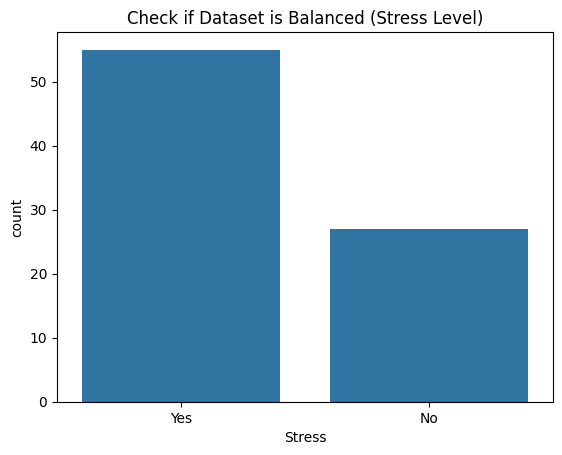

Stress
Yes    55
No     27
Name: count, dtype: int64


In [25]:
sns.countplot(x='Stress', data=df)
plt.title('Check if Dataset is Balanced (Stress Level)')
plt.show()

# Check balance
print(df['Stress'].value_counts())

In [26]:
df.drop_duplicates(subset=['Email'], keep='first', inplace=True)

In [27]:
#Removing km and Rs from columns for data wrangling
df['Distance'] = df['Distance'].astype(str).str.extract(r'(\d+)').astype(float)
df['Cost'] = df['Cost'].astype(str).str.extract(r'(\d+)').astype(float)
df.head()

,Timestamp,Name,Email,Age,Transport,Distance,Cost,Time,Stress,Fuel,Issue,Late,Activity,Change
0,2026/03/11 4:22:03 PM GMT+5,Syed Waleed Hussain,syedwaleedhussain89@gmail.com,22,"Public Transport (Bus, Metro, etc.)",49.0,200.0,More than 2 hours,Yes,NaN,Overcrowding,Yes,Listening to music or podcasts,"Yes, definitely"
1,2026/03/11 4:24:55 PM GMT+5,Ebrahim,ebrahimmoin35@gmail.com,21,"Public Transport (Bus, Metro, etc.)",27.0,300.0,30 to 60 minutes,Yes,NaN,NaN,No,Using social media / browsing my phone,"Yes, definitely"
2,2026/03/11 4:28:35 PM GMT+5,Ebraaahim,k230540@nu.edu.pk,21,Private Car / Motorcycle,21.0,250.0,1 to 2 hours,Yes,NaN,NaN,NaN,NaN,NaN
3,2026/03/11 4:28:52 PM GMT+5,Hashir Ahmed,hashirbijarani@gmail.com,21,Private Car / Motorcycle,21.0,500.0,30 to 60 minutes,Yes,20000,Overcrowding,Yes,Using social media / browsing my phone,I would have to think about it.
5,2026/03/11 4:29:39 PM GMT+5,Suleman Farhan,solufarhan9@gmail.com,21,Private Car / Motorcycle,22.0,900.0,30 to 60 minutes,No,10000,NaN,No,I drive myself,"No, I am satisfied"


In [28]:
#Handling Missing values
df['Fuel'] = df['Fuel'].fillna(0)
df['Distance'] = df['Distance'].fillna(df['Distance'].median())
df['Cost'] = df['Cost'].fillna(df['Cost'].median())

In [41]:
df.isnull().sum()

,0
Timestamp,0
Name,0
Email,0
Age,0
Distance,0
Cost,0
Time,0
Stress,0
Fuel,0
Issue,13


In [42]:
df['Issue'] = df['Issue'].fillna('No Specific Issue')
df['Late'] = df['Late'].fillna(df['Late'].mode()[0])
df['Activity'] = df['Activity'].fillna(df['Activity'].mode()[0])
df['Change'] = df['Change'].fillna(df['Change'].mode()[0])

print(df.isnull().sum())

Timestamp                                                            0
Name                                                                 0
Email                                                                0
Age                                                                  0
Distance                                                             0
Cost                                                                 0
Time                                                                 0
Stress                                                               0
Fuel                                                                 0
Issue                                                                0
Late                                                                 0
Activity                                                             0
Change                                                               0
Transport_Public Transport (Bus, Metro, etc.)                        0
Transp

In [44]:
df['Fuel'] = df['Fuel'].astype(str).str.replace('k', '000').str.extract(r'(\d+)').astype(float).fillna(0)

In [29]:
# Encoding Stress
le = LabelEncoder()
df['Stress'] = le.fit_transform(df['Stress']) # converting Yes=1, No=0

# Encoding Transport (One-Hot)
df = pd.get_dummies(df, columns=['Transport'], drop_first=True)

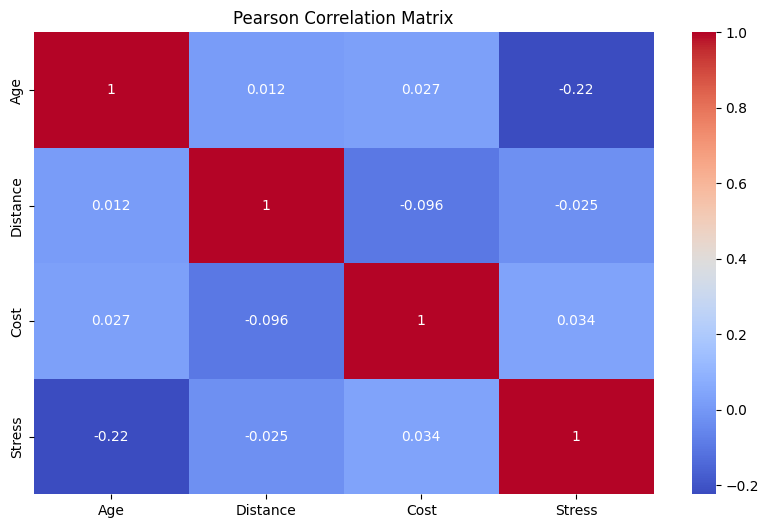

In [30]:
# Pearson Correlation
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Pearson Correlation Matrix')
plt.show()

# Feature Scaling Stress(Yes/No) is the output so take it as y and other columns and a features
scaler = StandardScaler()
X = numeric_df.drop('Stress', axis=1)
y = numeric_df['Stress']
X_scaled = scaler.fit_transform(X)

In [35]:
# 80% Train, 20% Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=0)

# 70% Train, 30% Validation (from the 80% train part)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.30, random_state=0)

# Apply KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print(f"Training Accuracy:",knn.score(X_train, y_train))
print(f"Testing Accuracy:",knn.score(X_test, y_test))

Training Accuracy: 0.75
Testing Accuracy: 0.6470588235294118


In [36]:
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {}

for m in metrics:
    model = KNeighborsClassifier(n_neighbors=5, metric=m)
    model.fit(X_train, y_train)
    results[m] = {
        'Train': accuracy_score(y_train, model.predict(X_train)),
        'Test': accuracy_score(y_test, model.predict(X_test))
    }

print("\nComparison Table:")
print(pd.DataFrame(results))


Comparison Table:
       euclidean  manhattan  minkowski
Train   0.750000   0.750000   0.750000
Test    0.647059   0.588235   0.647059


# Critical Analysis
**Data Collection:** We collected responses from 83 individuals, which is more than the required minimum of 50 .




**Survey Findings:** Most people who travel long distances (like 40-50 km) reported feeling high stress.

**Cleaning the Data:** The raw data had many errors, such as people writing "20km" or "Rs. 500". We used Python to extract only the numbers so the model could understand them.

**Comparing Metrics:** Euclidean Distance was the best, reaching 64.7% accuracy. It measures the straight-line distance between data points.Manhattan Distance was lower at 58.8%. It works like walking through city blocks and was less accurate for this specific commute data.


**Accuracy Gap:** Our training accuracy was 75%, but the test accuracy was 64.7%. This small gap means the model learned the training data well but struggled slightly with new, unseen people.


**Why Validation?:** We used a Validation Set to test different settings (like Euclidean vs. Manhattan) without "cheating" by looking at the final test data too early.

In [45]:
df.to_csv('Cleaned_Commute_Survey_Data.csv', index=False)

from google.colab import files
files.download('Cleaned_Commute_Survey_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>